In [137]:
import random
import numpy as np
import pandas as pd

MAX_MOVES =  20

P_INJURY = 0.10

#probability that prober retaliator probes
P_PROBE  =  1.0

#probability of retaliation after recieving a probe
P_RETALIATE = 1.0

WIN_PAYOFF = 60
INJURY_PAYOFF = -100
SCRATCH_PAYOFF = -2

#energy saving payoff
MAX_TIME_PAYOFF= 20
N_CONTESTS = 2000

random.seed(42)
np.random.seed(42)


In [138]:
C = "C"
D = "D"
R = "R"


In [139]:
class Contestant:
    def __init__(self, strategy):
        self.strategy = strategy

        #whether this contestant has been injured
        self.injured = False
        self.d_received = 0

        #number of serious injuries
        self.serious_injuries = 0

        #history of my own moves
        self.my_history = []

        #history of opponent's moves
        self.opponent_history = []
        

In [140]:
#a probe occurs when the contestant plays D on the first move or the contestant plays D in response to C

In [141]:
def is_probe(my_move, opponent_previous_move):
    #check whether D move counts as a probe
    if my_move != D:
        return False

    if opponent_previous_move is None:
        return True
    if opponent_previous_move == C:
        return True

    return False
    

In [142]:
def mouse_move(my_history, opponent_history):
    #mouse strategy is to always do C or retreat if opp does D
    if opponent_history:
        if opponent_history[-1] == D:
            return R

    return C

In [143]:
def hawk_move(my_history, opponent_history):
    return D # hawk always does D

In [144]:
def bully_move(my_history, opponent_history):
    #plays D initially, plays D in response to C, plays C in response to D, retreats if opponent has played D twice
    if len(opponent_history) == 0:
        return D

    #count previous D moves by opponent
    opponent_D_count = opponent_history.count(D)

    #retreat after opponent has played D twice
    if opponent_D_count >= 2:
        return R

    #if opponent's previous move was D, play C
    if opponent_history[-1] == C:
        return D

    if opponent_history[-1] == C:
        return 
        
    return C

In [145]:
def retaliator_move(my_history, opponent_history):
    
    # Retreat if maximum duration has been reached
    if len(my_history) >= MAX_MOVES:
        return R
    
    # First move
    if len(opponent_history) == 0:
        return C
    
    # Opponent uses D → retaliate
    if opponent_history[-1] == D:
        return D
    
    # Opponent uses C → remain conventional
    if opponent_history[-1] == C:
        return C
    
    return C

In [146]:
def prober_retaliator_move(my_history, opponent_history):
    
    # Retreat at maximum duration
    if len(my_history) >= MAX_MOVES:
        return R
    
    # First move
    if len(opponent_history) == 0:
        if random.random() < P_PROBE:
            return D
        else:
            return C
    
    opponent_last = opponent_history[-1]
    
    # ------------------------------------------------
    # Opponent used D
    # ------------------------------------------------
    
    if opponent_last == D:
        
        # Retaliate with probability P_RETALIATE
        if random.random() < P_RETALIATE:
            return D
        else:
            return C
    
    # ------------------------------------------------
    # Opponent used C
    # ------------------------------------------------
    
    if opponent_last == C:
        
        # If WE previously played D,
        # check whether opponent retaliated.
        
        if my_history[-1] == D:
            
            # Opponent played C in response to our D.
            # Take advantage and continue D.
            return D
        
        # Otherwise choose whether to probe
        if random.random() < P_PROBE:
            return D
        else:
            return C
    
    return C

In [147]:
STRATEGIES = {
    "Mouse": mouse_move,
    "Hawk": hawk_move,
    "Bully": bully_move,
    "Retaliator": retaliator_move,
    "Prober-Retaliator": prober_retaliator_move
}

In [148]:
print(STRATEGIES.keys())

dict_keys(['Mouse', 'Hawk', 'Bully', 'Retaliator', 'Prober-Retaliator'])


In [149]:
def process_D_received(contestant):
    
    contestant.d_received += 1
    
    # Determine whether serious injury occurs
    if random.random() < P_INJURY:
        
        contestant.injured = True
        contestant.serious_injuries += 1
        
        return "injury"
    
    else:
        return "scratch"

In [157]:
def run_contest(strategy_A_name, strategy_B_name, verbose=False):
    
    A = Contestant(strategy_A_name)
    B = Contestant(strategy_B_name)
    
    strategy_A = STRATEGIES[strategy_A_name]
    strategy_B = STRATEGIES[strategy_B_name]
    
    contest_log = []
    
    for move_number in range(1, MAX_MOVES + 1):
        
        move_A = strategy_A(
            A.my_history,
            A.opponent_history
        )
        
        move_B = strategy_B(
            B.my_history,
            B.opponent_history
        )
        
        A.my_history.append(move_A)
        B.my_history.append(move_B)
        
        A.opponent_history.append(move_B)
        B.opponent_history.append(move_A)
        
        result_A = None
        result_B = None
        
        if move_A == D:
            result_B = process_D_received(B)
        
        if move_B == D:
            result_A = process_D_received(A)
        
        contest_log.append({
            "move": move_number,
            "A": move_A,
            "B": move_B,
            "A_result": result_A,
            "B_result": result_B
        })
        
        if A.injured or B.injured:
            break
        
        if move_A == R or move_B == R:
            break
    
    # Determine winner
    if A.injured and not B.injured:
        winner = "B"
        
    elif B.injured and not A.injured:
        winner = "A"
        
    elif move_A == R and move_B != R:
        winner = "B"
        
    elif move_B == R and move_A != R:
        winner = "A"
        
    else:
        winner = random.choice(["A", "B"])
    
    n_moves = len(contest_log)
    
    payoff_A = calculate_payoff(
        A, winner, "A", n_moves
    )
    
    payoff_B = calculate_payoff(
        B, winner, "B", n_moves
    )
    
    return {
        "strategy_A": strategy_A_name,
        "strategy_B": strategy_B_name,
        "payoff_A": payoff_A,
        "payoff_B": payoff_B,
        "winner": winner,
        "moves": n_moves,
        "A_injured": A.injured,
        "B_injured": B.injured,
        "A_D_received": A.d_received,
        "B_D_received": B.d_received,
        "log": contest_log
    }

In [151]:
A, B, log, winner = run_contest(
    "Hawk",
    "Mouse"
)

print("Winner:", winner)
print()

for event in log:
    print(event)

Winner: A

{'move': 1, 'A': 'D', 'B': 'C', 'A_result': None, 'B_result': 'scratch'}
{'move': 2, 'A': 'D', 'B': 'R', 'A_result': None, 'B_result': 'injury'}


In [152]:
def print_contest(log):
    
    print("Move | Player A | Player B | Result A | Result B")
    print("-" * 55)
    
    for event in log:
        print(
            f"{event['move']:4d} | "
            f"{event['A']:8s} | "
            f"{event['B']:8s} | "
            f"{str(event['A_result']):8s} | "
            f"{str(event['B_result']):8s}"
        )

In [153]:
A, B, log, winner = run_contest(
    "Prober-Retaliator",
    "Prober-Retaliator"
)

print_contest(log)

print("\nWinner:", winner)

Move | Player A | Player B | Result A | Result B
-------------------------------------------------------
   1 | D        | D        | scratch  | scratch 
   2 | D        | D        | injury   | scratch 

Winner: B


In [154]:
def time_energy_payoff(n_moves):
    
    if n_moves >= MAX_MOVES:
        return 0
    
    return MAX_TIME_PAYOFF * (
        1 - (n_moves - 1) / (MAX_MOVES - 1)
    )

In [155]:
for n in [1, 5, 10, 15, 20]:
    print(n, time_energy_payoff(n))

1 20.0
5 15.789473684210527
10 10.526315789473685
15 5.2631578947368425
20 0


In [156]:
def calculate_payoff(contestant, winner, player_label, n_moves):
    
    payoff = 0
    
    # -------------------------
    # Winning payoff
    # -------------------------
    
    if winner == player_label:
        payoff += WIN_PAYOFF
    
    # -------------------------
    # Injury payoff
    # -------------------------
    
    if contestant.injured:
        payoff += INJURY_PAYOFF
    
    # -------------------------
    # Scratch costs
    # -------------------------
    
    # Every D received that did not
    # cause serious injury = scratch
    scratches = (
        contestant.d_received
        - contestant.serious_injuries
    )
    
    payoff += scratches * SCRATCH_PAYOFF
    
    # -------------------------
    # Time/energy payoff
    # -------------------------
    
    # Only contestants not seriously injured
    # receive this benefit.
    if not contestant.injured:
        payoff += time_energy_payoff(n_moves)
    
    return payoff

In [158]:
result = run_contest(
    "Hawk",
    "Mouse"
)

print("Strategy A:", result["strategy_A"])
print("Strategy B:", result["strategy_B"])
print("Winner:", result["winner"])
print("Moves:", result["moves"])
print("Payoff A:", result["payoff_A"])
print("Payoff B:", result["payoff_B"])

Strategy A: Hawk
Strategy B: Mouse
Winner: A
Moves: 2
Payoff A: 78.94736842105263
Payoff B: 14.947368421052634


In [159]:
def simulate_matchup(strategy_A, strategy_B, n_contests=N_CONTESTS):
    
    payoffs_A = []
    payoffs_B = []
    
    results = []
    
    for _ in range(n_contests):
        
        result = run_contest(
            strategy_A,
            strategy_B
        )
        
        payoffs_A.append(result["payoff_A"])
        payoffs_B.append(result["payoff_B"])
        
        results.append(result)
    
    return {
        "mean_A": np.mean(payoffs_A),
        "mean_B": np.mean(payoffs_B),
        "all_results": results
    }

In [160]:
matchup = simulate_matchup(
    "Hawk",
    "Mouse"
)

print("Hawk:", matchup["mean_A"])
print("Mouse:", matchup["mean_B"])

Hawk: 79.04947368421054
Mouse: -5.792210526315788


In [161]:
strategy_names = [
    "Mouse",
    "Hawk",
    "Bully",
    "Retaliator",
    "Prober-Retaliator"
]

In [162]:
from itertools import combinations_with_replacement

pairings = list(
    combinations_with_replacement(
        strategy_names,
        2
    )
)

for pair in pairings:
    print(pair)

print("\nNumber of pairings:", len(pairings))

('Mouse', 'Mouse')
('Mouse', 'Hawk')
('Mouse', 'Bully')
('Mouse', 'Retaliator')
('Mouse', 'Prober-Retaliator')
('Hawk', 'Hawk')
('Hawk', 'Bully')
('Hawk', 'Retaliator')
('Hawk', 'Prober-Retaliator')
('Bully', 'Bully')
('Bully', 'Retaliator')
('Bully', 'Prober-Retaliator')
('Retaliator', 'Retaliator')
('Retaliator', 'Prober-Retaliator')
('Prober-Retaliator', 'Prober-Retaliator')

Number of pairings: 15


In [163]:
all_results = []

for strategy_A, strategy_B in pairings:
    
    print(
        f"Running {strategy_A} vs {strategy_B}..."
    )
    
    matchup = simulate_matchup(
        strategy_A,
        strategy_B,
        N_CONTESTS
    )
    
    all_results.append({
        "strategy_A": strategy_A,
        "strategy_B": strategy_B,
        "payoff_A": matchup["mean_A"],
        "payoff_B": matchup["mean_B"]
    })

Running Mouse vs Mouse...
Running Mouse vs Hawk...
Running Mouse vs Bully...
Running Mouse vs Retaliator...
Running Mouse vs Prober-Retaliator...
Running Hawk vs Hawk...
Running Hawk vs Bully...
Running Hawk vs Retaliator...
Running Hawk vs Prober-Retaliator...
Running Bully vs Bully...
Running Bully vs Retaliator...
Running Bully vs Prober-Retaliator...
Running Retaliator vs Retaliator...
Running Retaliator vs Prober-Retaliator...
Running Prober-Retaliator vs Prober-Retaliator...


In [164]:
results_df = pd.DataFrame(all_results)

results_df

,strategy_A,strategy_B,payoff_A,payoff_B
0,Mouse,Mouse,30.090000,29.910000
1,Mouse,Hawk,-6.084579,79.049474
2,Mouse,Bully,-6.946684,79.057368
3,Mouse,Retaliator,30.960000,29.040000
4,Mouse,Prober-Retaliator,-7.784316,79.047368
5,Hawk,Hawk,-23.809474,-22.964789
6,Hawk,Bully,60.625263,-12.427895
7,Hawk,Retaliator,-13.846105,-34.021421
8,Hawk,Prober-Retaliator,-26.433895,-21.216526
9,Bully,Bully,23.939684,22.070789


In [165]:
payoff_matrix = pd.DataFrame(
    index=strategy_names,
    columns=strategy_names,
    dtype=float
)

In [166]:
for _, row in results_df.iterrows():
    
    A = row["strategy_A"]
    B = row["strategy_B"]
    
    payoff_A = row["payoff_A"]
    payoff_B = row["payoff_B"]
    
    payoff_matrix.loc[A, B] = payoff_A
    payoff_matrix.loc[B, A] = payoff_B

In [167]:
print(
    payoff_matrix.round(2)
)


                   Mouse   Hawk  Bully  Retaliator  Prober-Retaliator
Mouse              29.91  -6.08  -6.95       30.96              -7.78
Hawk               79.05 -22.96  60.63      -13.85             -26.43
Bully              79.06 -12.43  22.07        5.62             -10.30
Retaliator         29.04 -34.02  40.94       28.65             -36.20
Prober-Retaliator  79.05 -21.22  60.43      -10.30             -24.28


In [168]:

for strategy in strategy_names:
    
    column = payoff_matrix[strategy]
    
    best_response = column.idxmax()
    
    print(
        f"Population strategy: {strategy}"
    )
    print(
        f"Best response: {best_response}"
    )
    print(
        f"{strategy} vs itself: {column[strategy]:.2f}"
    )
    print()

Population strategy: Mouse
Best response: Bully
Mouse vs itself: 29.91

Population strategy: Hawk
Best response: Mouse
Hawk vs itself: -22.96

Population strategy: Bully
Best response: Hawk
Bully vs itself: 22.07

Population strategy: Retaliator
Best response: Mouse
Retaliator vs itself: 28.65

Population strategy: Prober-Retaliator
Best response: Mouse
Prober-Retaliator vs itself: -24.28



In [179]:
def population_payoffs(frequencies, payoff_matrix):
    
    # Expected game payoff of each strategy
    payoffs = payoff_matrix.values @ frequencies
    
    return payoffs

def payoff_to_fitness(payoffs, beta=0.01):
    
    fitness = np.exp(beta * payoffs)
    
    return fitness

In [181]:
def replicator_step(
    frequencies,
    payoff_matrix,
    beta=0.01
):
    
    # Step 1: calculate expected payoff
    payoffs = payoff_matrix.values @ frequencies
    
    # Step 2: convert payoff to positive fitness
    fitness = np.exp(beta * payoffs)
    
    # Step 3: mean fitness
    mean_fitness = np.sum(
        frequencies * fitness
    )
    
    # Step 4: reproduction
    new_frequencies = (
        frequencies * fitness
    ) / mean_fitness
    
    return new_frequencies

In [182]:
frequencies = np.ones(5) / 5

print(frequencies)

[0.2 0.2 0.2 0.2 0.2]


In [183]:
trajectory = []

for generation in range(500):
    
    trajectory.append(
        frequencies.copy()
    )
    
    frequencies = replicator_step(
        frequencies,
        payoff_matrix
    )

In [184]:
trajectory_df = pd.DataFrame(
    trajectory,
    columns=strategy_names
)

trajectory_df["generation"] = np.arange(
    len(trajectory_df)
)

trajectory_df.head()

,Mouse,Hawk,Bully,Retaliator,Prober-Retaliator,generation
0,0.200000,0.200000,0.200000,0.200000,0.200000,0
1,0.191001,0.205415,0.208560,0.186606,0.208418,1
2,0.181588,0.211056,0.216703,0.173428,0.217224,2
3,0.171917,0.216851,0.224334,0.160540,0.226358,3
4,0.162136,0.222727,0.231372,0.148013,0.235752,4


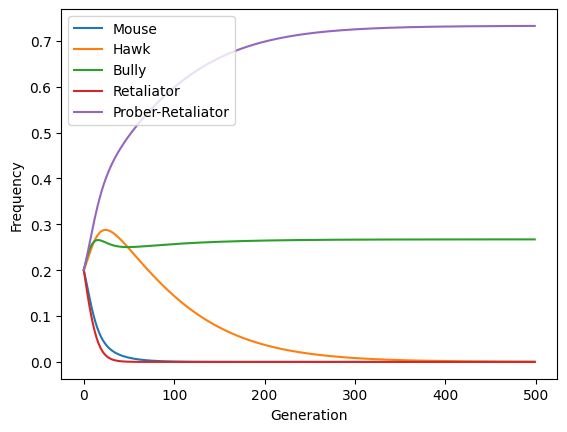

In [185]:
import matplotlib.pyplot as plt

for strategy in strategy_names:
    
    plt.plot(
        trajectory_df["generation"],
        trajectory_df[strategy],
        label=strategy
    )

plt.xlabel("Generation")
plt.ylabel("Frequency")
plt.legend()
plt.show()